# Predykcja cen mieszkań - Raport nr 2

**Przedmiot:** Metody analizy, przetwarzania i wizualizacji danych  
**Autorzy:** Jakub Nowosad, Łukasz Iwanek, Piotr Białas  
**Data:** 12.04.2026

---

W tym raporcie zajmujemy się czyszczeniem i przetwarzaniem danych. Zanim zaczniemy budować modele, musimy naprawić problemy znalezione w raporcie nr 1 - uzupełnić braki, usunąć podejrzane rekordy, zakodować zmienne kategoryczne i znormalizować dane.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/ames_housing.csv')
print(f'Wczytano: {df.shape[0]} wierszy, {df.shape[1]} kolumn')

Wczytano: 1460 wierszy, 81 kolumn


## 1. Problemy znalezione w danych

### 1.1 Braki danych

W raporcie nr 1 zidentyfikowaliśmy 19 kolumn z brakami. Poniżej zestawienie:

In [2]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Braki': missing,
    'Procent [%]': missing_pct
}).query('Braki > 0').sort_values('Procent [%]', ascending=False)

print(f'Kolumny z brakami: {len(missing_df)} / {len(df.columns)}')
print(f'Łączna liczba brakujących wartości: {missing.sum()}')
print()
missing_df

Kolumny z brakami: 19 / 81
Łączna liczba brakujących wartości: 7829



,Braki,Procent [%]
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


Po przejrzeniu dokumentacji zbioru okazało się, że większość braków to nie błędy - NaN w kolumnach takich jak PoolQC, FireplaceQu czy GarageType oznacza po prostu, że dom nie ma basenu, kominka czy garażu. Tylko `LotFrontage` (17.7%) ma faktycznie brakujące pomiary, a `Electrical` ma 1 brak wyglądający na pomyłkę.

### 1.2 Wartości odstające

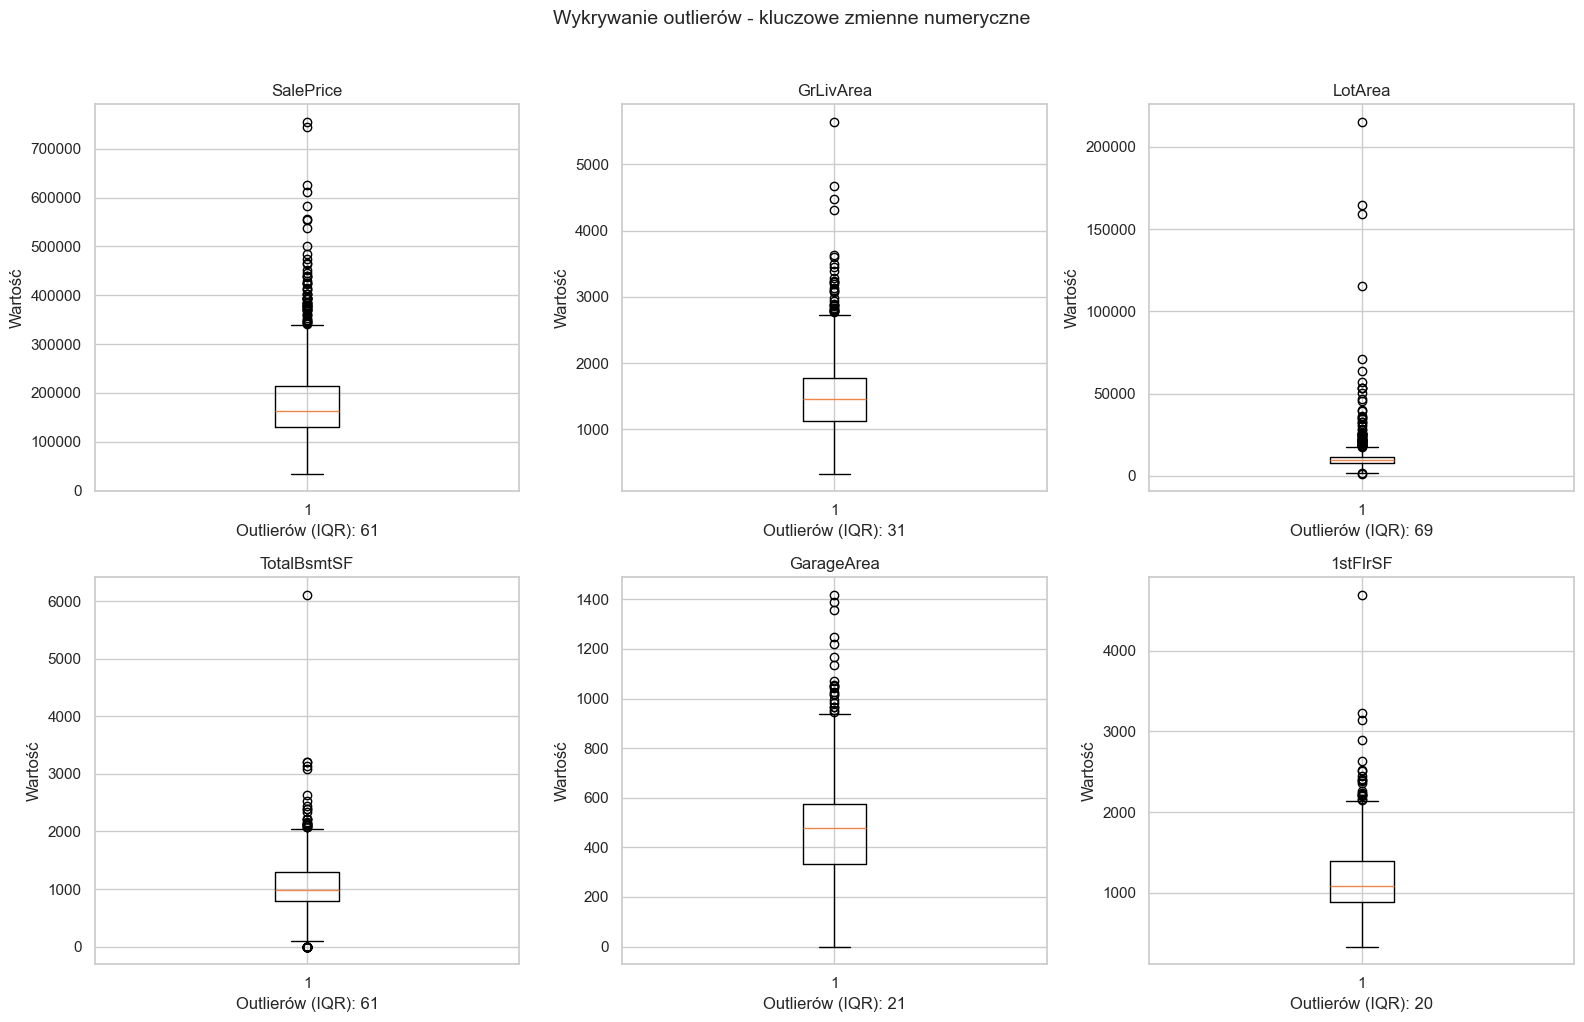

In [3]:
key_numeric = ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), key_numeric):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel('Wartość')
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    ax.set_xlabel(f'Outlierów (IQR): {outliers}')

plt.suptitle('Wykrywanie outlierów - kluczowe zmienne numeryczne', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/09_outliers_boxplots.png', bbox_inches='tight')
plt.show()

Metodą IQR wykryliśmy sporo outlierów (np. 69 w LotArea, 61 w SalePrice), ale większość to naturalna zmienność rynku nieruchomości. Skupiliśmy się na naprawdę podejrzanych przypadkach:

### 1.3 Podejrzane rekordy

In [4]:
# garaż zbudowany po sprzedaży domu?
garage_future = df[df['GarageYrBlt'] > df['YrSold']]
print(f'Garaże z rokiem budowy > rok sprzedaży: {len(garage_future)}')

# remont przed budową?
remod_before_built = df[df['YearRemodAdd'] < df['YearBuilt']]
print(f'Remont przed budową domu: {len(remod_before_built)}')

print()

# ekstremalnie duże działki
huge_lots = df[df['LotArea'] > 100000]
print(f'Działki > 100 000 sqft (przy medianie ~9500): {len(huge_lots)}')
if len(huge_lots) > 0:
    print(huge_lots[['Id', 'LotArea', 'SalePrice', 'Neighborhood']].to_string())

print()

# duże domy sprzedane za bardzo mało
suspicious = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print(f'Domy > 4000 sqft sprzedane za < $300k: {len(suspicious)}')
if len(suspicious) > 0:
    print(suspicious[['Id', 'GrLivArea', 'SalePrice', 'OverallQual']].to_string())

Garaże z rokiem budowy > rok sprzedaży: 0
Remont przed budową domu: 0

Działki > 100 000 sqft (przy medianie ~9500): 4
      Id  LotArea  SalePrice Neighborhood
249  250   159000     277000      ClearCr
313  314   215245     375000       Timber
335  336   164660     228950       Timber
706  707   115149     302000      ClearCr

Domy > 4000 sqft sprzedane za < $300k: 2
        Id  GrLivArea  SalePrice  OverallQual
523    524       4676     184750           10
1298  1299       5642     160000           10


Błędów logicznych nie znaleźliśmy. Natomiast 2 domy z powierzchnią >4000 sqft i jakością 10/10 sprzedane za 160-185 tys. dolarów wyglądają na transakcje pozarynkowe. Dodatkowo 4 działki mają ekstremalną powierzchnię (ponad 10x więcej niż mediana).

---

## 2. Rozwiązanie problemów

### 2.1 Usunięcie bezużytecznych kolumn

In [5]:
df_clean = df.copy()

df_clean = df_clean.drop('Id', axis=1)

high_missing = missing_pct[missing_pct > 80].index.tolist()
print(f'Usuwamy kolumny z >80% braków: {high_missing}')
df_clean = df_clean.drop(columns=high_missing)
print(f'Zostało: {df_clean.shape}')

Usuwamy kolumny z >80% braków: ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Zostało: (1460, 76)


Usunęliśmy kolumnę Id (numer porządkowy) oraz 4 kolumny z ponad 80% braków - PoolQC, MiscFeature, Alley i Fence. Przy tak dużym odsetku braków sensowna imputacja nie jest możliwa, a w raporcie nr 1 widzieliśmy, że te cechy słabo korelują z ceną.

### 2.2 Uzupełnienie braków - zmienne kategoryczne

In [6]:
none_cols = ['FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    if col in df_clean.columns:
        n_filled = df_clean[col].isnull().sum()
        df_clean[col] = df_clean[col].fillna('None')
        print(f'  {col}: {n_filled} braków -> "None"')

mode_val = df_clean['Electrical'].mode()[0]
df_clean['Electrical'] = df_clean['Electrical'].fillna(mode_val)
print(f'  Electrical: 1 brak -> "{mode_val}" (moda)')

  FireplaceQu: 690 braków -> "None"
  GarageType: 81 braków -> "None"
  GarageFinish: 81 braków -> "None"
  GarageQual: 81 braków -> "None"
  GarageCond: 81 braków -> "None"
  BsmtQual: 37 braków -> "None"
  BsmtCond: 37 braków -> "None"
  BsmtExposure: 38 braków -> "None"
  BsmtFinType1: 37 braków -> "None"
  BsmtFinType2: 38 braków -> "None"
  MasVnrType: 872 braków -> "None"
  Electrical: 1 brak -> "SBrkr" (moda)


W kolumnach gdzie NaN oznacza brak cechy wstawiliśmy "None". Dla Electrical (1 brak) wstawiliśmy najczęstszą wartość.

### 2.3 Uzupełnienie braków - zmienne numeryczne

In [7]:
n_before = df_clean['LotFrontage'].isnull().sum()
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
print(f'LotFrontage: {n_before} braków -> mediana wg dzielnicy')

n_before = df_clean['MasVnrArea'].isnull().sum()
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)
print(f'MasVnrArea: {n_before} braków -> 0')

n_before = df_clean['GarageYrBlt'].isnull().sum()
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(0)
print(f'GarageYrBlt: {n_before} braków -> 0')

print(f'\nPozostałe braki: {df_clean.isnull().sum().sum()}')

LotFrontage: 259 braków -> mediana wg dzielnicy
MasVnrArea: 8 braków -> 0
GarageYrBlt: 81 braków -> 0

Pozostałe braki: 0


Dla LotFrontage (259 braków) użyliśmy mediany w ramach dzielnicy - domy w tej samej okolicy mają zbliżone rozmiary działek. MasVnrArea i GarageYrBlt uzupełniliśmy zerami (brak okładziny / brak garażu).

### 2.4 Usunięcie outlierów

In [8]:
n_before = len(df_clean)

df_clean = df_clean[~((df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000))]
df_clean = df_clean[df_clean['LotArea'] <= 100000]

print(f'Usunięto {n_before - len(df_clean)} outlierów')
print(f'Rozmiar zbioru: {n_before} -> {len(df_clean)}')

Usunięto 6 outlierów
Rozmiar zbioru: 1460 -> 1454


Usunęliśmy 6 rekordów (< 0.5% zbioru): 2 podejrzane transakcje i 4 ekstremalnie duże działki.

---

## 3. Transformacje i metody preprocessingu

### 3.1 Transformacja logarytmiczna SalePrice

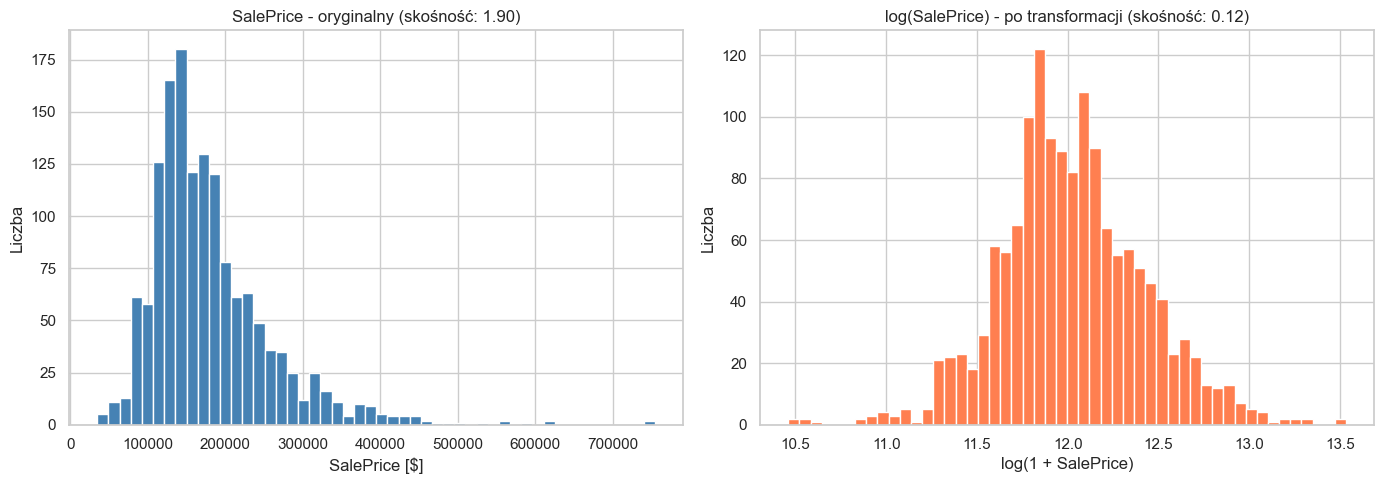

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'SalePrice - oryginalny (skośność: {df_clean["SalePrice"].skew():.2f})')
axes[0].set_xlabel('SalePrice [$]')
axes[0].set_ylabel('Liczba')

df_clean['SalePrice_log'] = np.log1p(df_clean['SalePrice'])

axes[1].hist(df_clean['SalePrice_log'], bins=50, color='coral', edgecolor='white')
axes[1].set_title(f'log(SalePrice) - po transformacji (skośność: {df_clean["SalePrice_log"].skew():.2f})')
axes[1].set_xlabel('log(1 + SalePrice)')
axes[1].set_ylabel('Liczba')

plt.tight_layout()
plt.savefig('../reports/figures/10_log_transform.png', bbox_inches='tight')
plt.show()

Cena miała prawoskośny rozkład (skośność 1.90). Po transformacji log(1+x) rozkład jest zbliżony do normalnego (skośność 0.12), co jest korzystne dla modeli regresyjnych.

### 3.2 Kodowanie zmiennych kategorycznych

In [10]:
ordinal_mapping = {
    'ExterQual':    {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'ExterCond':    {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual':     {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtCond':     {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'HeatingQC':    {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual':  {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'FireplaceQu':  {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageQual':   {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond':   {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'Functional':   {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'LotShape':     {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'LandSlope':    {'Sev': 1, 'Mod': 2, 'Gtl': 3},
    'PavedDrive':   {'N': 0, 'P': 1, 'Y': 2},
    'CentralAir':   {'N': 0, 'Y': 1},
}

for col, mapping in ordinal_mapping.items():
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(mapping)

print(f'Ordinal encoding: {len(ordinal_mapping)} kolumn')

Ordinal encoding: 18 kolumn


In [11]:
remaining_cat = df_clean.select_dtypes(include=['object', 'str']).columns.tolist()

label_encoders = {}
for col in remaining_cat:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

print(f'Label encoding: {len(remaining_cat)} kolumn')
print(f'Kolumny: {remaining_cat}')

Label encoding: 21 kolumn
Kolumny: ['MSZoning', 'Street', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition']


Zastosowaliśmy dwa rodzaje kodowania:
- **Ordinal encoding** (18 zmiennych) - dla cech z naturalnym porządkiem, np. jakość: Po(1) < Fa(2) < TA(3) < Gd(4) < Ex(5). Ręcznie przypisaliśmy wartości zachowując porządek.
- **Label encoding** (pozostałe) - dla cech bez porządku (np. dzielnica, typ dachu). Każda kategoria dostała liczbowy kod.

### 3.3 Standaryzacja zmiennych numerycznych

In [12]:
target_cols = ['SalePrice', 'SalePrice_log']
ordinal_cols = list(ordinal_mapping.keys())
label_encoded_cols = remaining_cat

numeric_to_scale = [col for col in df_clean.select_dtypes(include=[np.number]).columns
                    if col not in target_cols + ordinal_cols + label_encoded_cols]

scaler = StandardScaler()
df_clean[numeric_to_scale] = scaler.fit_transform(df_clean[numeric_to_scale])

print(f'Standaryzacja: {len(numeric_to_scale)} kolumn')
print(f'\nPrzykład (pierwsze 5):')
df_clean[numeric_to_scale[:5]].describe().round(2)

Standaryzacja: 36 kolumn

Przykład (pierwsze 5):


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond
count,1454.00,1454.00,1454.00,1454.00,1454.00
mean,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.87,-2.29,-1.61,-3.70,-4.11
25%,-0.87,-0.46,-0.46,-0.79,-0.52
50%,-0.16,0.00,-0.11,-0.07,-0.52
75%,0.31,0.47,0.28,0.66,0.38
max,3.15,11.37,11.21,2.84,3.07


Zmienne ciągłe zestandaryzowaliśmy za pomocą StandardScaler (średnia=0, std=1). Nie skalowaliśmy zmiennej docelowej ani zmiennych ordinalnych.

---

## 4. Podsumowanie

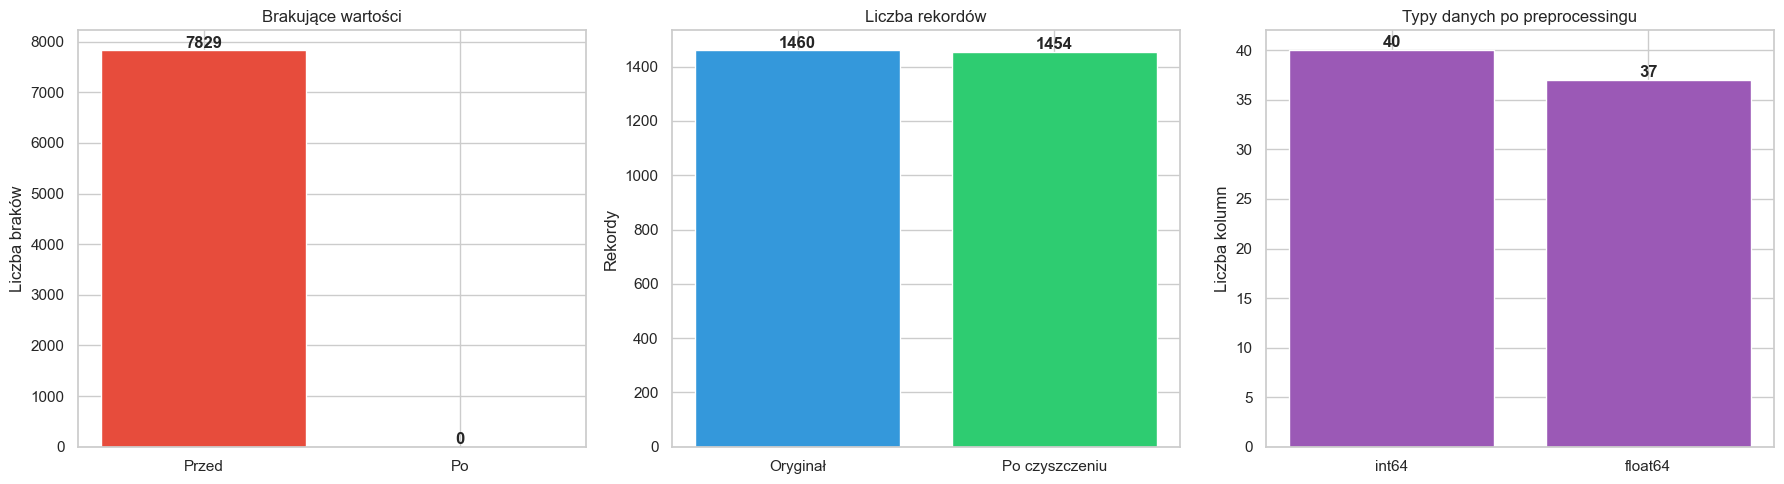

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

missing_before = df.isnull().sum().sum()
missing_after = df_clean.isnull().sum().sum()
axes[0].bar(['Przed', 'Po'], [missing_before, missing_after], color=['#e74c3c', '#27ae60'])
axes[0].set_title('Brakujące wartości')
axes[0].set_ylabel('Liczba braków')
for i, v in enumerate([missing_before, missing_after]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].bar(['Oryginał', 'Po czyszczeniu'], [len(df), len(df_clean)], color=['#3498db', '#2ecc71'])
axes[1].set_title('Liczba rekordów')
axes[1].set_ylabel('Rekordy')
for i, v in enumerate([len(df), len(df_clean)]):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

dtypes_after = df_clean.dtypes.value_counts()
axes[2].bar(dtypes_after.index.astype(str), dtypes_after.values, color='#9b59b6')
axes[2].set_title('Typy danych po preprocessingu')
axes[2].set_ylabel('Liczba kolumn')
for i, v in enumerate(dtypes_after.values):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/11_preprocessing_summary.png', bbox_inches='tight')
plt.show()

In [14]:
print(f'Oryginał:          {df.shape[0]} wierszy x {df.shape[1]} kolumn')
print(f'Po preprocessingu: {df_clean.shape[0]} wierszy x {df_clean.shape[1]} kolumn')
print(f'Braki danych:      {df.isnull().sum().sum()} -> {df_clean.isnull().sum().sum()}')
print(f'Duplikaty:         {df_clean.duplicated().sum()}')
print(f'Typy kolumn:       {dict(df_clean.dtypes.value_counts())}')

Oryginał:          1460 wierszy x 81 kolumn
Po preprocessingu: 1454 wierszy x 77 kolumn
Braki danych:      7829 -> 0
Duplikaty:         0
Typy kolumn:       {dtype('int64'): np.int64(40), dtype('float64'): np.int64(37)}


In [15]:
df_clean.to_csv('../data/ames_housing_clean.csv', index=False)
print(f'Zapisano: data/ames_housing_clean.csv')

Zapisano: data/ames_housing_clean.csv


## Screeny z narzędzia (PyCharm)

**Struktura projektu:**

![Struktura projektu](../reports/figures/screen_pycharm_1.png)

**Notebook w edytorze:**

![Notebook w edytorze](../reports/figures/screen_pycharm_2.png)

**Podgląd wykresu:**

![Podgląd wykresu](../reports/figures/screen_pycharm_3.png)


## 5. Ocena gotowości danych

Dane są gotowe do budowy modeli. Po preprocessingu mamy 1454 rekordów i 77 kolumn, zero braków, wszystko w formacie numerycznym.

Co zrobiliśmy:
- usunęliśmy 4 kolumny z >80% braków i kolumnę Id,
- uzupełniliśmy braki ("None" dla brakujących cech, mediana wg dzielnicy dla LotFrontage, moda dla Electrical),
- usunęliśmy 6 outlierów (< 0.5% zbioru),
- zastosowaliśmy transformację logarytmiczną ceny (skośność 1.90 -> 0.12),
- zakodowaliśmy zmienne kategoryczne (18 ordinalnie, resztę label encoderem),
- zestandaryzowaliśmy zmienne ciągłe (StandardScaler).

Zbiór jest kompletny i gotowy pod modele regresyjne. W kolejnym etapie zajmiemy się budową i porównaniem modeli.